In [13]:
# Load necessary libraries
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(fixest)
library(lubridate)
library(ggtext)


Attaching package: ‘lubridate’


The following objects are masked from ‘package:data.table’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [2]:
# Custom colors from the provided image 
flexible_color <- "#4C515C"  # Replace with the exact hex code for Flexible
cosy_color <- "#5F8ED9"      # Replace with the exact hex code for Cosy
hp_color <- "#AD87CA"
not_hp_color <- "#2D354A"


In [3]:
# Read the CSV file for EV charging events
ev_charging <- fread("../data/input/cosy_-_ev_detection_2024_07_04.csv") %>%
  mutate(ev_charging = 1)

head(ev_charging)

account_id,hashed_mpan,interval_start,read_value,ev_charging
<int>,<int>,<dttm>,<dbl>,<dbl>
6787,936933584,2023-06-15 00:00:00,3.755,1
6787,936933584,2023-06-15 00:30:00,3.779,1
6787,936933584,2023-06-15 01:00:00,3.790,1
6787,936933584,2023-06-15 01:30:00,3.764,1
6787,936933584,2023-06-15 02:00:00,3.811,1
6787,936933584,2023-06-15 02:30:00,3.760,1


In [5]:
# Read the files (HP Installation, Cosy Adoption and Daily Weather)
hp <- fread("../data/input/cosy_-_half_hourly_data_for_hp_sample_2024_09_26.csv") %>%
    rename(interval_start = adjusted_interval_start)

# weather data
weather <- fread("../data/input/Cosy Analysis Weather Mar 26 daily.csv") %>% 
  rename_with(.cols = starts_with("weekly"), 
              .fn = ~ sub("^weekly", "daily", .)) %>%
  rename(tariff_gsp_group_id=gsp_group_id) %>%
  mutate(date=as.Date(date_day, format = "%Y-%m-%d"))

# Select some random mpans
# set.seed(12345)
# sample_selection <- sample(unique(hp$account_id), 350)
  
# Create Treatment dummy and Settlement Categorical
hp <- hp %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(fread("../data/input/cosy_-_hp_details_2024_06_25.csv") %>% distinct(hashed_mpan, .keep_all=TRUE), by=c("hashed_mpan")) %>%
  mutate(settlement_date = as.Date(interval_start),
         installed_at = as.Date(installed_at),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_hp_installed = as.numeric(installed_at <= settlement_date)
                            ) %>%
  left_join(weather, by = c("settlement_date" = "date", "tariff_gsp_group_id")) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   # Read the CSV file for EV charging events


hp <- hp %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging))

length(unique(hp$hashed_mpan))


Joining with `by = join_by(interval_start, account_id)`


[1] 417

In [6]:
# Event study style regressions
# Midnight is the omitted category

m_hourly_hp <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_hp_installed, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  data =  hp)

# clean up
rm(hp)
gc()


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1211297,64.7,2030354,108.5,1429203,76.4
Vcells,1083558194,8266.9,4086605757,31178.4,3610497700,27546.0


In [7]:
# load cosy first adoption
first_adoption <- readRDS("../data/scratch/aggregated_data.RDS") %>%
  ungroup() %>%
  select(hashed_mpan, first_adoption, account_id, tariff_gsp_group_id) %>%
  distinct(hashed_mpan, first_adoption, .keep_all=TRUE)

# Read the files (Cosy Adoption)
cosy <- fread("../data/input/cosy_-_half_hourly_data_for_cosy_sample_2024_10_29.csv") %>%
   rename(interval_start = adjusted_interval_start)

# Select some random mpans
#set.seed(12345)
#sample_selection <- sample(unique(cosy$mpan_hashed), 350)
  
# Create Treatment dummy and Settlement Categorical
cosy <- cosy %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(first_adoption, by = "hashed_mpan") %>%
  mutate(settlement_date = as.Date(interval_start),
         first_adoption = as.Date(first_adoption),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_cosy = as.numeric(first_adoption<=settlement_date)) %>%
  left_join(weather, by = c("settlement_date" = "date", c("tariff_gsp_group_id"="tariff_gsp_group_id"))) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   

# Charging events
cosy <- cosy %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging))



Joining with `by = join_by(interval_start, account_id)`


In [8]:

# Cosy analysis
m_hourly_cosy <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_cosy, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  data = cosy)


In [9]:
dim(cosy)

[1] 9452875      17

In [10]:
# Extract coefficients and standard errors
coefs_cosy <- coeftable(m_hourly_cosy) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(term, into = c("remove", "remove2", "settlement_period", "is_cosy"), sep = ":") %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "cosy") %>% 
  filter(!is.na(is_cosy)) %>%
  select(-c(remove, remove2, `t.value`, `Pr...t..`, is_cosy))

# Extract coefficients and standard errors
coefs_hp <- coeftable(m_hourly_hp) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(term, into = c("remove", "remove2", "settlement_period", "has_hp"), sep = ":") %>%
  mutate(settlement_period = as.numeric(settlement_period),
        treatment = "hp") %>% 
  filter(!is.na(has_hp))%>%
  select(-c(remove, remove2, `t.value`, `Pr...t..`, has_hp)) 


# merge together
coefs <- full_join(coefs_cosy, coefs_hp) %>%
  mutate(lower_ci = Estimate - 1.96 * Std..Error,
    upper_ci = Estimate + 1.96 * Std..Error)

# Function to convert settlement period to time
settlement_period_to_time <- function(period) {
  hours <- (period - 1) %/% 2
  minutes <- ifelse((period %% 2) == 1, "00", "30")
  sprintf("%02d:%s", hours, minutes)
}

# Apply the function to create time labels
coefs <- coefs %>%
  mutate(time_label = settlement_period_to_time(settlement_period))


head(coefs)

Warning message:
“Expected 4 pieces. Missing pieces filled with `NA` in 47 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Warning message:
“Expected 4 pieces. Missing pieces filled with `NA` in 47 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Joining with `by = join_by(settlement_period, Estimate, Std..Error, treatment)`


settlement_period,Estimate,Std..Error,treatment,lower_ci,upper_ci,time_label
<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,0.003529207,0.02852453,cosy,-0.05237888,0.0594372903,00:00
2,-0.067836080,0.02794651,cosy,-0.12261125,-0.0130609107,00:30
3,-0.056481422,0.02857706,cosy,-0.11249245,-0.0004703933,01:00
4,-0.083109807,0.03050681,cosy,-0.14290315,-0.0233164639,01:30
5,-0.092910478,0.03323432,cosy,-0.15804975,-0.0277712018,02:00
6,-0.098706751,0.03479526,cosy,-0.16690547,-0.0305080360,02:30


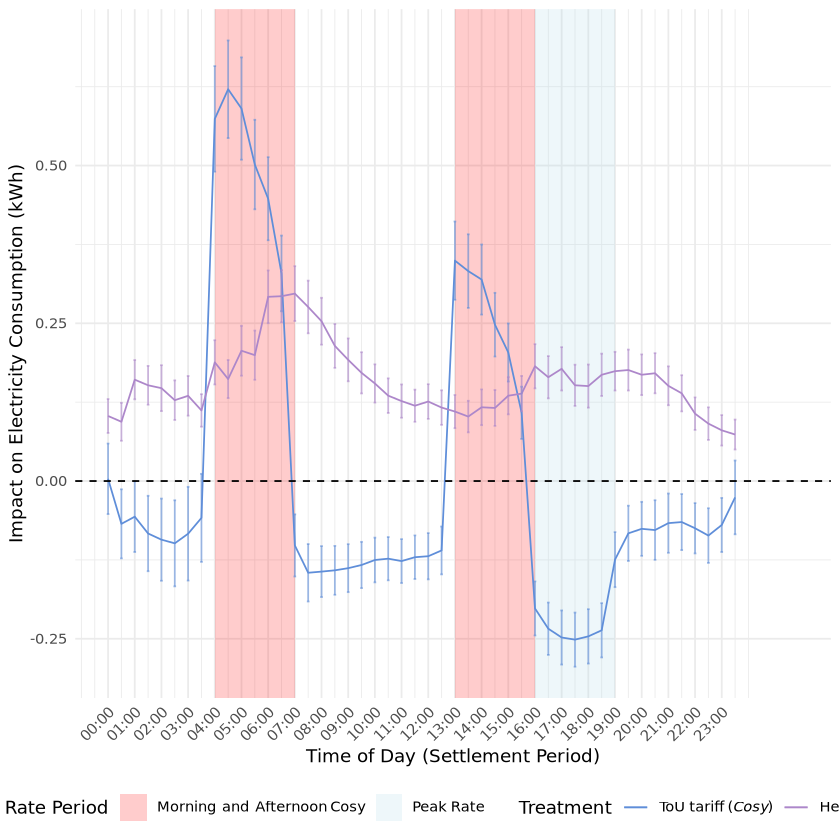

In [11]:
# Apply the function to create time label
# Select a few representative time labels to display for clarity
selected_periods <- seq(min(coefs$settlement_period), max(coefs$settlement_period), by = 2)
display_labels <- coefs %>%
  filter(settlement_period %in% selected_periods) %>%
  distinct(settlement_period, time_label) %>%
  pull(time_label)


# Define the time periods for shading (settlement periods converted to numeric for xmin, xmax)
shaded_periods <- data.frame(
  xmin = c(9, 27, 33),  # 4-7 AM (periods 8-14), 1-4 PM (periods 26-32), 4-7 PM (periods 34-40)
  xmax = c(15, 33, 39),
  period_type = c("Morning and Afternoon Cosy", "Morning and Afternoon Cosy", "Peak Rate")
)

# Create the ggplot
ggplot(coefs, aes(x = settlement_period, y = Estimate, group = treatment, color = treatment)) +
  # Add shaded rectangles using the shaded_periods data
  geom_rect(data = shaded_periods, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = period_type),
            inherit.aes = FALSE, alpha = 0.2) +   # Add transparency and disable inherited aesthetics
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  scale_color_manual(
    name = "Treatment", 
    labels = c("hp" = "Heat Pump", "cosy" = "ToU tariff (*Cosy*)"),  # Italicizing Cosy using markdown
    values = c("hp" = hp_color, "cosy" = cosy_color)
  ) +
  scale_fill_manual(
    name = "Rate Period",  # Correct the fill legend
    values = c("Morning and Afternoon Cosy" = "red", "Peak Rate" = "lightblue"),  # Assign the correct colors
    labels = c("Morning and Afternoon Cosy" = "Morning and Afternoon Cosy", "Peak Rate" = "Peak Rate")
  ) +
  labs(
    x = "Time of Day (Settlement Period)",
    y = "Impact on Electricity Consumption (kWh)",
    color = "Treatment",
    fill = "Rate Period"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_markdown()  # Enable markdown-style formatting for the legend
  ) +
  scale_x_continuous(
    breaks = selected_periods,  # Ensure you define 'selected_periods' correctly
    labels = display_labels,    # Ensure 'display_labels' are defined or generated from 'settlement_period'
    expand = expansion(mult = c(0.05, 0.15))
  ) + 
  geom_hline(yintercept = 0, linetype = "dashed", color = "black")   # Add horizontal line at y = 0




In [12]:
# Save the plot if necessary
ggsave("../graphs/combined_impact_hourly_consumption.png", width = 10, height = 6, dpi = 300)


In [18]:
# add the week day / weekend analysis
cosy <- cosy %>%
    mutate(wday = wday(interval_start, label =TRUE),
          weekend = wday %in% c("Sun", "Sat"))

# Cosy analysis
m_hourly_cosy <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_cosy, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  split = ~ weekend,
                  data = cosy)

,,m_hourly_cosy[[1]]
,<chr>,<chr>
1,Sample (weekend),FALSE
2,Dependent Var.:,read_value
3,,
4,settlement_period = 2,0.0595* (0.0233)
5,settlement_period = 3,0.0585* (0.0257)
6,settlement_period = 4,0.0888** (0.0329)
7,settlement_period = 5,0.1318*** (0.0362)
8,settlement_period = 6,0.1430*** (0.0350)
9,settlement_period = 7,0.1469*** (0.0363)


In [19]:
# same for the HP analysis

# clean up
rm(cosy)
gc()

# Read the files (HP Installation, Cosy Adoption and Daily Weather)
hp <- fread("../data/input/cosy_-_half_hourly_data_for_hp_sample_2024_09_26.csv") %>%
    rename(interval_start = adjusted_interval_start)

# weather data
weather <- fread("../data/input/Cosy Analysis Weather Mar 26 daily.csv") %>% 
  rename_with(.cols = starts_with("weekly"), 
              .fn = ~ sub("^weekly", "daily", .)) %>%
  rename(tariff_gsp_group_id=gsp_group_id) %>%
  mutate(date=as.Date(date_day, format = "%Y-%m-%d"))

# Select some random mpans
# set.seed(12345)
# sample_selection <- sample(unique(hp$account_id), 350)
  
# Create Treatment dummy and Settlement Categorical
hp <- hp %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(fread("../data/input/cosy_-_hp_details_2024_06_25.csv") %>% distinct(hashed_mpan, .keep_all=TRUE), by=c("hashed_mpan")) %>%
  mutate(settlement_date = as.Date(interval_start),
         installed_at = as.Date(installed_at),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_hp_installed = as.numeric(installed_at <= settlement_date)
                            ) %>%
  left_join(weather, by = c("settlement_date" = "date", "tariff_gsp_group_id")) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   # Read the CSV file for EV charging events

# add EV charging, and weekend dummies
hp <- hp %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging),
         wday = wday(interval_start, label =TRUE),
         weekend = wday %in% c("Sun", "Sat"))


# Event study style regressions
# Midnight is the omitted category

m_hourly_hp <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_hp_installed, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                     split = ~ weekend,
                  data =  hp)



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1558201,83.3,2879611,153.8,2879611,153.8
Vcells,2034300690,15520.5,5501777195,41975.3,6877221493,52469.1


Joining with `by = join_by(interval_start, account_id)`


In [55]:
# Extract coefficients and standard errors
coefs_cosy <- coeftable(m_hourly_cosy) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(coefficient, into = c("part1", "part2"), sep = "::") %>%
  separate(part2, into = c("settlement_period", "is_cosy"), sep = ":")  %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "cosy") %>% 
  filter(!is.na(is_cosy)) %>%
  select(-c(part1, `t.value`, `Pr...t..`, is_cosy, term, sample.var, id))

# Extract coefficients and standard errors
coefs_hp <- coeftable(m_hourly_hp) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(coefficient, into = c("part1", "part2"), sep = "::") %>%
  separate(part2, into = c("settlement_period", "has_hp"), sep = ":")  %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "hp") %>% 
  filter(!is.na(has_hp)) %>%
  select(-c(part1, `t.value`, `Pr...t..`, has_hp, term, sample.var, id))

# merge together
coefs <- full_join(coefs_cosy, coefs_hp) %>%
  mutate(lower_ci = Estimate - 1.96 * Std..Error,
    upper_ci = Estimate + 1.96 * Std..Error)

# Function to convert settlement period to time
settlement_period_to_time <- function(period) {
  hours <- (period - 1) %/% 2
  minutes <- ifelse((period %% 2) == 1, "00", "30")
  sprintf("%02d:%s", hours, minutes)
}

# Apply the function to create time labels
coefs <- coefs %>%
  mutate(time_label = settlement_period_to_time(settlement_period))


head(coefs)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 94 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 94 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Joining with `by = join_by(sample, settlement_period, Estimate, Std..Error,
treatment)`


sample,settlement_period,Estimate,Std..Error,treatment,lower_ci,upper_ci,time_label
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
FALSE,1,0.003966953,0.02875551,cosy,-0.05239385,0.060327754,00:00
FALSE,2,-0.068476108,0.02834071,cosy,-0.12402390,-0.012928314,00:30
FALSE,3,-0.057886802,0.02902275,cosy,-0.11477138,-0.001002219,01:00
FALSE,4,-0.085624084,0.03087547,cosy,-0.14614001,-0.025108158,01:30
FALSE,5,-0.095289450,0.03322902,cosy,-0.16041833,-0.030160566,02:00
FALSE,6,-0.098535260,0.03482384,cosy,-0.16678999,-0.030280527,02:30


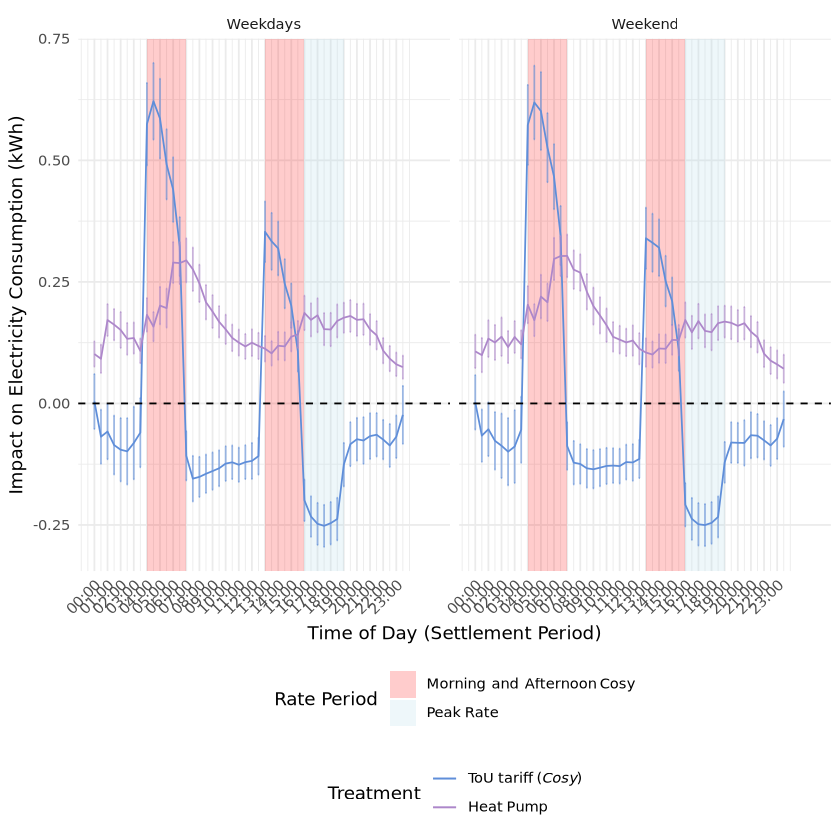

In [58]:
# Apply the function to create time label
# Select a few representative time labels to display for clarity
selected_periods <- seq(min(coefs$settlement_period), max(coefs$settlement_period), by = 2)
display_labels <- coefs %>%
  filter(settlement_period %in% selected_periods) %>%
  distinct(settlement_period, time_label) %>%
  pull(time_label)

# Define the time periods for shading (settlement periods converted to numeric for xmin, xmax)
shaded_periods <- data.frame(
  xmin = c(9, 27, 33),  # 4-7 AM (periods 8-14), 1-4 PM (periods 26-32), 4-7 PM (periods 34-40)
  xmax = c(15, 33, 39),
  period_type = c("Morning and Afternoon Cosy", "Morning and Afternoon Cosy", "Peak Rate")
)

# Create the ggplot
ggplot(coefs, aes(x = settlement_period, y = Estimate, group = treatment, color = treatment)) +
  # Add shaded rectangles using the shaded_periods data
  geom_rect(data = shaded_periods, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = period_type),
            inherit.aes = FALSE, alpha = 0.2) +   # Add transparency and disable inherited aesthetics
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  scale_color_manual(
    name = "Treatment", 
    labels = c("hp" = "Heat Pump", "cosy" = "ToU tariff (*Cosy*)"),  # Italicizing Cosy using markdown
    values = c("hp" = hp_color, "cosy" = cosy_color)
  ) +
  scale_fill_manual(
    name = "Rate Period",  # Correct the fill legend
    values = c("Morning and Afternoon Cosy" = "red", "Peak Rate" = "lightblue"),  # Assign the correct colors
    labels = c("Morning and Afternoon Cosy" = "Morning and Afternoon Cosy", "Peak Rate" = "Peak Rate")
  ) +
  labs(
    x = "Time of Day (Settlement Period)",
    y = "Impact on Electricity Consumption (kWh)",
    color = "Treatment",
    fill = "Rate Period"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_markdown(),  # Enable markdown-style formatting for the legend
    legend.box = "vertical"  # Stack legend items in a vertical box
  ) +
  guides(
    color = guide_legend(nrow = 2),   # Set legend rows for color
    fill = guide_legend(nrow = 2)     # Set legend rows for fill
  ) +
  scale_x_continuous(
    breaks = selected_periods,  # Ensure you define 'selected_periods' correctly
    labels = display_labels,    # Ensure 'display_labels' are defined or generated from 'settlement_period'
    expand = expansion(mult = c(0.05, 0.15))
  ) + 
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  facet_wrap(~ sample, labeller = as_labeller(c(`FALSE` = "Weekdays", `TRUE` = "Weekend")))

In [59]:
# Save the plot if necessary
ggsave("../graphs/combined_impact_hourly_consumption_weekend.png", width = 10, height = 6, dpi = 300)


In [71]:
# same thing for temperature
# Read the files (HP Installation, Cosy Adoption and Daily Weather)
hp <- fread("../data/input/cosy_-_half_hourly_data_for_hp_sample_2024_09_26.csv") %>%
    rename(interval_start = adjusted_interval_start)

# weather data
weather <- fread("../data/input/Cosy Analysis Weather Mar 26 daily.csv") %>% 
  rename_with(.cols = starts_with("weekly"), 
              .fn = ~ sub("^weekly", "daily", .)) %>%
  rename(tariff_gsp_group_id=gsp_group_id) %>%
  mutate(date=as.Date(date_day, format = "%Y-%m-%d"))

# Select some random mpans
# set.seed(12345)
# sample_selection <- sample(unique(hp$account_id), 350)
  
# Create Treatment dummy and Settlement Categorical
hp <- hp %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(fread("../data/input/cosy_-_hp_details_2024_06_25.csv") %>% distinct(hashed_mpan, .keep_all=TRUE), by=c("hashed_mpan")) %>%
  mutate(settlement_date = as.Date(interval_start),
         installed_at = as.Date(installed_at),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_hp_installed = as.numeric(installed_at <= settlement_date)
                            ) %>%
  left_join(weather, by = c("settlement_date" = "date", "tariff_gsp_group_id")) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   # Read the CSV file for EV charging events

# add EV charging, and weekend dummies
hp <- hp %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging),
         wday = wday(interval_start, label =TRUE),
         weekend = wday %in% c("Sun", "Sat"))


hp <- hp %>% 
  mutate(temp_degree = factor(
    case_when(
      daily_avg_air_temperature_celsius < 5 ~ "Under 5",
      daily_avg_air_temperature_celsius < 15 ~ "Under 15",
      TRUE ~ "Over 15")))

m_hourly_hp <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_hp_installed, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                     split = ~ temp_degree,
                  data =  hp)

rm(hp)
gc()


Joining with `by = join_by(interval_start, account_id)`


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1636069,87.4,2879611,153.8,2879611,153.8
Vcells,2195899425,16753.4,6510132027,49668.4,8476651076,64671.8


In [70]:
# load cosy first adoption
first_adoption <- readRDS("../data/scratch/aggregated_data.RDS") %>%
  ungroup() %>%
  select(hashed_mpan, first_adoption, account_id, tariff_gsp_group_id) %>%
  distinct(hashed_mpan, first_adoption, .keep_all=TRUE)

# Read the files (Cosy Adoption)
cosy <- fread("../data/input/cosy_-_half_hourly_data_for_cosy_sample_2024_10_29.csv") %>%
   rename(interval_start = adjusted_interval_start)

# Select some random mpans
#set.seed(12345)
#sample_selection <- sample(unique(cosy$mpan_hashed), 350)
  
# Create Treatment dummy and Settlement Categorical
cosy <- cosy %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(first_adoption, by = "hashed_mpan") %>%
  mutate(settlement_date = as.Date(interval_start),
         first_adoption = as.Date(first_adoption),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_cosy = as.numeric(first_adoption<=settlement_date)) %>%
  left_join(weather, by = c("settlement_date" = "date", c("tariff_gsp_group_id"="tariff_gsp_group_id"))) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   

# Charging events
cosy <- cosy %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging)) %>% 
  mutate(temp_degree = factor(
    case_when(
      daily_avg_air_temperature_celsius < 5 ~ "Under 5",
      daily_avg_air_temperature_celsius < 15 ~ "Under 15",
      TRUE ~ "Over 15")))


# Cosy analysis
m_hourly_cosy <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_cosy, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  split = ~ temp_degree,
                  data = cosy)


Joining with `by = join_by(interval_start, account_id)`


In [72]:
# Extract coefficients and standard errors
coefs_cosy <- coeftable(m_hourly_cosy) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(coefficient, into = c("part1", "part2"), sep = "::") %>%
  separate(part2, into = c("settlement_period", "is_cosy"), sep = ":")  %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "cosy") %>% 
  filter(!is.na(is_cosy)) %>%
  select(-c(part1, `t.value`, `Pr...t..`, is_cosy, term, sample.var, id))

# Extract coefficients and standard errors
coefs_hp <- coeftable(m_hourly_hp) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(coefficient, into = c("part1", "part2"), sep = "::") %>%
  separate(part2, into = c("settlement_period", "has_hp"), sep = ":")  %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "hp") %>% 
  filter(!is.na(has_hp)) %>%
  select(-c(part1, `t.value`, `Pr...t..`, has_hp, term, sample.var, id))

# merge together
coefs <- full_join(coefs_cosy, coefs_hp) %>%
  mutate(lower_ci = Estimate - 1.96 * Std..Error,
    upper_ci = Estimate + 1.96 * Std..Error)

# Function to convert settlement period to time
settlement_period_to_time <- function(period) {
  hours <- (period - 1) %/% 2
  minutes <- ifelse((period %% 2) == 1, "00", "30")
  sprintf("%02d:%s", hours, minutes)
}

# Apply the function to create time labels
coefs <- coefs %>%
  mutate(time_label = settlement_period_to_time(settlement_period))


head(coefs)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 141 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 141 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Joining with `by = join_by(sample, settlement_period, Estimate, Std..Error,
treatment)`


sample,settlement_period,Estimate,Std..Error,treatment,lower_ci,upper_ci,time_label
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Over 15,1,0.003275205,0.03303957,cosy,-0.06148234,0.068032754,00:00
Over 15,2,-0.036751221,0.03158717,cosy,-0.09866207,0.025159632,00:30
Over 15,3,-0.034316692,0.03198327,cosy,-0.09700389,0.028370509,01:00
Over 15,4,-0.057685634,0.03269591,cosy,-0.12176963,0.006398357,01:30
Over 15,5,-0.103883015,0.04252271,cosy,-0.18722753,-0.020538498,02:00
Over 15,6,-0.092329806,0.04045250,cosy,-0.17161670,-0.013042908,02:30


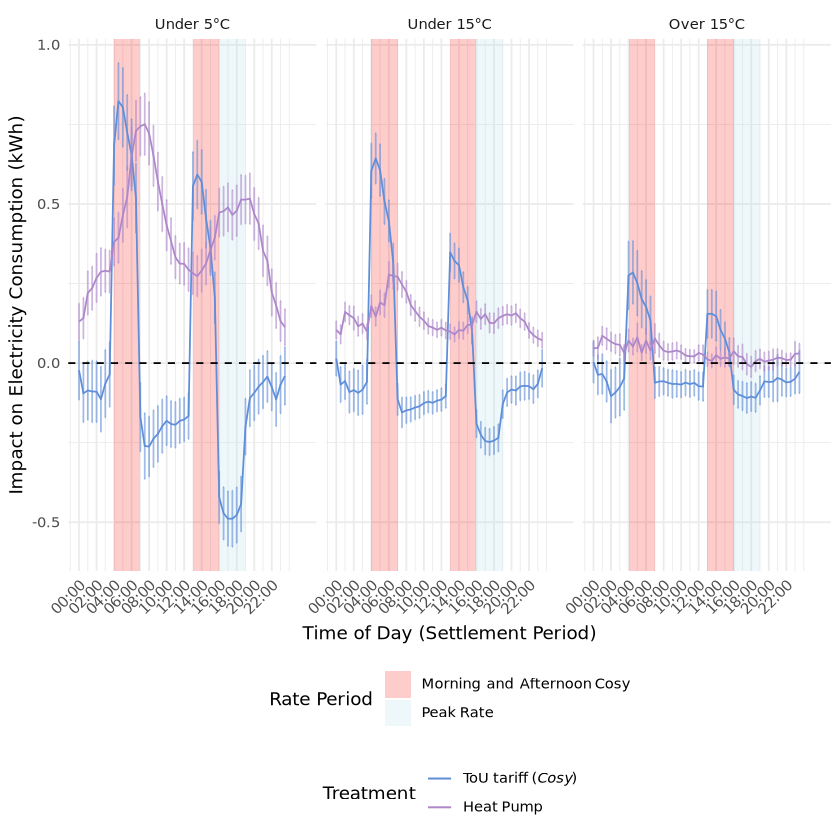

In [77]:
# Apply the function to create time label
# Select a few representative time labels to display for clarity
selected_periods <- seq(min(coefs$settlement_period), max(coefs$settlement_period), by = 4)
display_labels <- coefs %>%
  filter(settlement_period %in% selected_periods) %>%
  distinct(settlement_period, time_label) %>%
  pull(time_label)

# Define the time periods for shading (settlement periods converted to numeric for xmin, xmax)
shaded_periods <- data.frame(
  xmin = c(9, 27, 33),  # 4-7 AM (periods 8-14), 1-4 PM (periods 26-32), 4-7 PM (periods 34-40)
  xmax = c(15, 33, 39),
  period_type = c("Morning and Afternoon Cosy", "Morning and Afternoon Cosy", "Peak Rate")
)

# Change the sample order
coefs <- coefs %>%
    mutate(sample = factor(sample, levels = c("Under 5", "Under 15", "Over 15")))

# Create the ggplot
ggplot(coefs, aes(x = settlement_period, y = Estimate, group = treatment, color = treatment)) +
  # Add shaded rectangles using the shaded_periods data
  geom_rect(data = shaded_periods, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = period_type),
            inherit.aes = FALSE, alpha = 0.2) +   # Add transparency and disable inherited aesthetics
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  scale_color_manual(
    name = "Treatment", 
    labels = c("hp" = "Heat Pump", "cosy" = "ToU tariff (*Cosy*)"),  # Italicizing Cosy using markdown
    values = c("hp" = hp_color, "cosy" = cosy_color)
  ) +
  scale_fill_manual(
    name = "Rate Period",  # Correct the fill legend
    values = c("Morning and Afternoon Cosy" = "red", "Peak Rate" = "lightblue"),  # Assign the correct colors
    labels = c("Morning and Afternoon Cosy" = "Morning and Afternoon Cosy", "Peak Rate" = "Peak Rate")
  ) +
  labs(
    x = "Time of Day (Settlement Period)",
    y = "Impact on Electricity Consumption (kWh)",
    color = "Treatment",
    fill = "Rate Period"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_markdown(),  # Enable markdown-style formatting for the legend
    legend.box = "vertical"  # Stack legend items in a vertical box
  ) +
  guides(
    color = guide_legend(nrow = 2),   # Set legend rows for color
    fill = guide_legend(nrow = 2)     # Set legend rows for fill
  ) +
  scale_x_continuous(
    breaks = selected_periods,  # Ensure you define 'selected_periods' correctly
    labels = display_labels,    # Ensure 'display_labels' are defined or generated from 'settlement_period'
    expand = expansion(mult = c(0.05, 0.15))
  ) + 
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  facet_wrap(~ sample, labeller = labeller(
    sample = c("Under 5" = "Under 5°C", "Under 15" = "Under 15°C", "Over 15" = "Over 15°C")
  ))

In [78]:
# Save the plot if necessary
ggsave("../graphs/combined_impact_hourly_consumption_degrees.png", width = 10, height = 6, dpi = 300)


In [80]:
# let's do EV owners separetely
cosy <- cosy %>%
    group_by(account_id) %>%
    mutate(ev_owner = max(ev_charging)) 

# Cosy analysis
m_hourly_cosy <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_cosy, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  split = ~ ev_owner,
                  data = cosy)


In [81]:
rm(cosy)
gc()

# Read the files (HP Installation, Cosy Adoption and Daily Weather)
hp <- fread("../data/input/cosy_-_half_hourly_data_for_hp_sample_2024_09_26.csv") %>%
    rename(interval_start = adjusted_interval_start)

# weather data
weather <- fread("../data/input/Cosy Analysis Weather Mar 26 daily.csv") %>% 
  rename_with(.cols = starts_with("weekly"), 
              .fn = ~ sub("^weekly", "daily", .)) %>%
  rename(tariff_gsp_group_id=gsp_group_id) %>%
  mutate(date=as.Date(date_day, format = "%Y-%m-%d"))

# Select some random mpans
# set.seed(12345)
# sample_selection <- sample(unique(hp$account_id), 350)
  
# Create Treatment dummy and Settlement Categorical
hp <- hp %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(fread("../data/input/cosy_-_hp_details_2024_06_25.csv") %>% distinct(hashed_mpan, .keep_all=TRUE), by=c("hashed_mpan")) %>%
  mutate(settlement_date = as.Date(interval_start),
         installed_at = as.Date(installed_at),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_hp_installed = as.numeric(installed_at <= settlement_date)
                            ) %>%
  left_join(weather, by = c("settlement_date" = "date", "tariff_gsp_group_id")) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   # Read the CSV file for EV charging events

# add EV charging, and weekend dummies
hp <- hp %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging),
         wday = wday(interval_start, label =TRUE),
         weekend = wday %in% c("Sun", "Sat"))

hp <- hp %>%
    group_by(account_id) %>%
    mutate(ev_owner = max(ev_charging)) 

m_hourly_hp <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_hp_installed, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                     split = ~ ev_owner,
                  data =  hp)



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1639008,87.6,2879611,153.8,2879611,153.8
Vcells,2039915201,15563.4,6510132027,49668.4,8476651076,64671.8


Joining with `by = join_by(interval_start, account_id)`


In [91]:
# Extract coefficients and standard errors
coefs_cosy <- coeftable(m_hourly_cosy) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(coefficient, into = c("part1", "part2"), sep = "::") %>%
  separate(part2, into = c("settlement_period", "is_cosy"), sep = ":")  %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "cosy") %>% 
  filter(!is.na(is_cosy)) %>%
  select(-c(part1, `t.value`, `Pr...t..`, is_cosy, term, sample.var, id))

# Extract coefficients and standard errors
coefs_hp <- coeftable(m_hourly_hp) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(coefficient, into = c("part1", "part2"), sep = "::") %>%
  separate(part2, into = c("settlement_period", "has_hp"), sep = ":")  %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "hp") %>% 
  filter(!is.na(has_hp)) %>%
  select(-c(part1, `t.value`, `Pr...t..`, has_hp, term, sample.var, id))

# merge together
coefs <- full_join(coefs_cosy, coefs_hp) %>%
  mutate(lower_ci = Estimate - 1.96 * Std..Error,
    upper_ci = Estimate + 1.96 * Std..Error)

# Function to convert settlement period to time
settlement_period_to_time <- function(period) {
  hours <- (period - 1) %/% 2
  minutes <- ifelse((period %% 2) == 1, "00", "30")
  sprintf("%02d:%s", hours, minutes)
}

# Apply the function to create time labels
coefs <- coefs %>%
  mutate(time_label = settlement_period_to_time(settlement_period))


head(coefs)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 94 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 94 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Joining with `by = join_by(sample, settlement_period, Estimate, Std..Error,
treatment)`


sample,settlement_period,Estimate,Std..Error,treatment,lower_ci,upper_ci,time_label
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
0,1,-0.02147969,0.01977124,cosy,-0.06023132,0.017271935,00:00
0,2,-0.02811863,0.01600356,cosy,-0.05948562,0.003248352,00:30
0,3,-0.01544916,0.01691022,cosy,-0.04859319,0.017694872,01:00
0,4,-0.01004894,0.01722680,cosy,-0.04381347,0.023715588,01:30
0,5,-0.01487867,0.02133904,cosy,-0.05670318,0.026945851,02:00
0,6,-0.04511811,0.02884467,cosy,-0.10165366,0.011417436,02:30


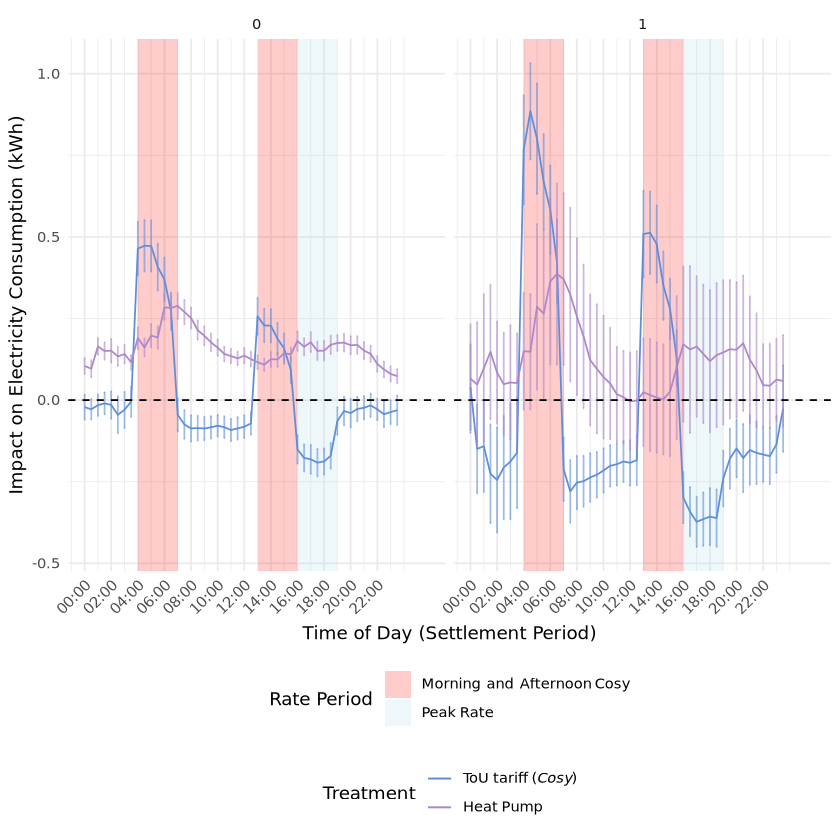

In [92]:
# Apply the function to create time label
# Select a few representative time labels to display for clarity
selected_periods <- seq(min(coefs$settlement_period), max(coefs$settlement_period), by = 4)
display_labels <- coefs %>%
  filter(settlement_period %in% selected_periods) %>%
  distinct(settlement_period, time_label) %>%
  pull(time_label)

# Define the time periods for shading (settlement periods converted to numeric for xmin, xmax)
shaded_periods <- data.frame(
  xmin = c(9, 27, 33),  # 4-7 AM (periods 8-14), 1-4 PM (periods 26-32), 4-7 PM (periods 34-40)
  xmax = c(15, 33, 39),
  period_type = c("Morning and Afternoon Cosy", "Morning and Afternoon Cosy", "Peak Rate")
)

# Create the ggplot
ggplot(coefs, aes(x = settlement_period, y = Estimate, group = treatment, color = treatment)) +
  # Add shaded rectangles using the shaded_periods data
  geom_rect(data = shaded_periods, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = period_type),
            inherit.aes = FALSE, alpha = 0.2) +   # Add transparency and disable inherited aesthetics
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  scale_color_manual(
    name = "Treatment", 
    labels = c("hp" = "Heat Pump", "cosy" = "ToU tariff (*Cosy*)"),  # Italicizing Cosy using markdown
    values = c("hp" = hp_color, "cosy" = cosy_color)
  ) +
  scale_fill_manual(
    name = "Rate Period",  # Correct the fill legend
    values = c("Morning and Afternoon Cosy" = "red", "Peak Rate" = "lightblue"),  # Assign the correct colors
    labels = c("Morning and Afternoon Cosy" = "Morning and Afternoon Cosy", "Peak Rate" = "Peak Rate")
  ) +
  labs(
    x = "Time of Day (Settlement Period)",
    y = "Impact on Electricity Consumption (kWh)",
    color = "Treatment",
    fill = "Rate Period"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_markdown(),  # Enable markdown-style formatting for the legend
    legend.box = "vertical"  # Stack legend items in a vertical box
  ) +
  guides(
    color = guide_legend(nrow = 2),   # Set legend rows for color
    fill = guide_legend(nrow = 2)     # Set legend rows for fill
  ) +
  scale_x_continuous(
    breaks = selected_periods,  # Ensure you define 'selected_periods' correctly
    labels = display_labels,    # Ensure 'display_labels' are defined or generated from 'settlement_period'
    expand = expansion(mult = c(0.05, 0.15))
  ) + 
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  facet_wrap(~ sample)